In [34]:
import pandas as pd

# Dataset load
df = pd.read_csv("../dataset/ai4i2020.csv")

# First 5 rows
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [35]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (10000, 14)

Column Names:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64

In [36]:
print("Machine Failure Distribution:")
print(df["Machine failure"].value_counts())

print("\nFailure Percentage:")
print(df["Machine failure"].value_counts(normalize=True) * 100)

Machine Failure Distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure Percentage:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [37]:
print(df.describe())

               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             10000.000000   
mean    5000.50000           300.004930               310.005560   
std     2886.89568             2.000259                 1.483734   
min        1.00000           295.300000               305.700000   
25%     2500.75000           298.300000               308.800000   
50%     5000.50000           300.100000               310.100000   
75%     7500.25000           301.500000               311.100000   
max    10000.00000           304.500000               313.800000   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]  Machine failure  \
count            10000.000000  10000.000000     10000.000000     10000.000000   
mean              1538.776100     39.986910       107.951000         0.033900   
std                179.284096      9.968934        63.654147         0.180981   
min               1168.000000      3.800000         0.000000   

In [38]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [39]:
df.groupby("Machine failure")[
    [
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]"
    ]
].mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


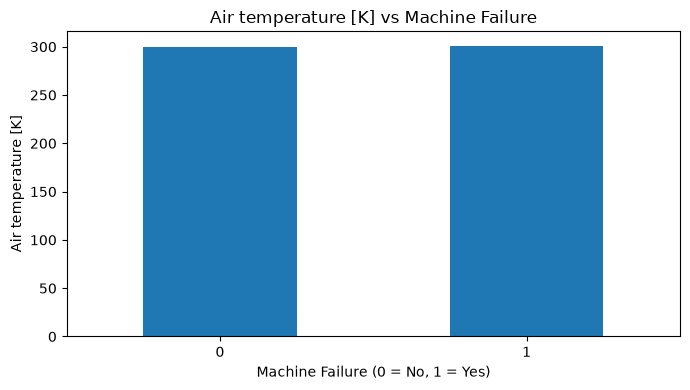

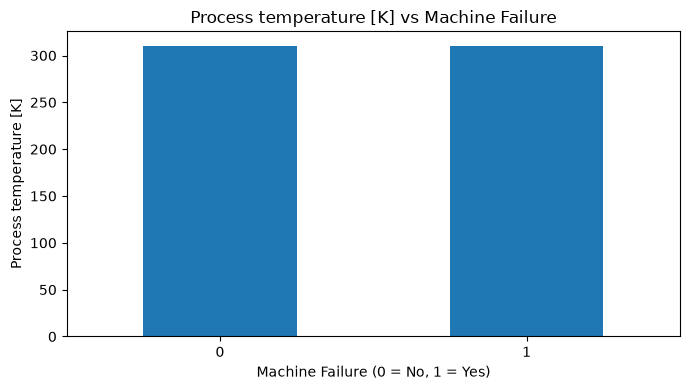

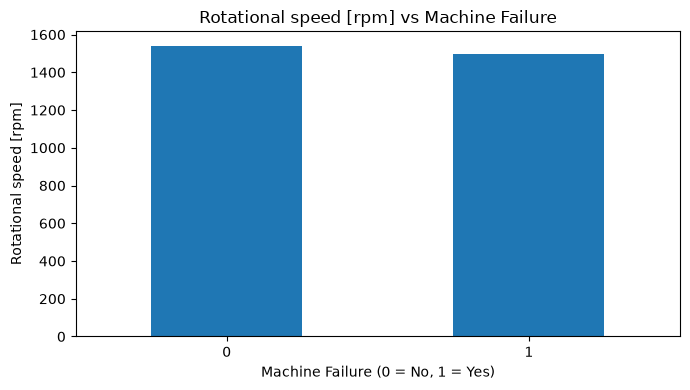

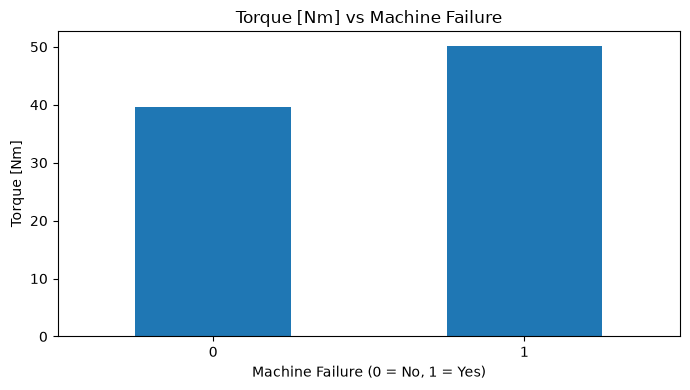

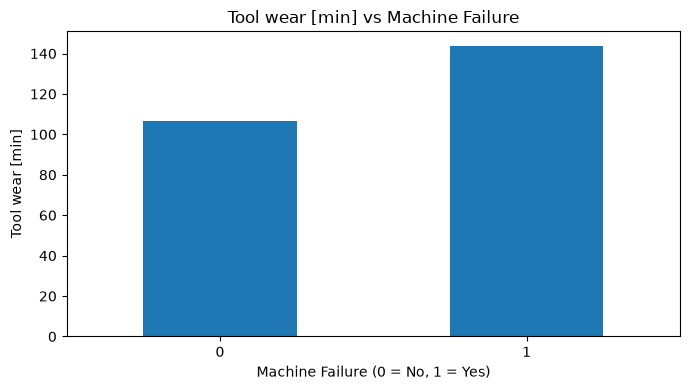

In [40]:
import matplotlib.pyplot as plt

features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for feature in features:
    plt.figure(figsize=(7, 4))
    df.groupby("Machine failure")[feature].mean().plot(kind="bar")
    plt.title(f"{feature} vs Machine Failure")
    plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
    plt.ylabel(feature)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

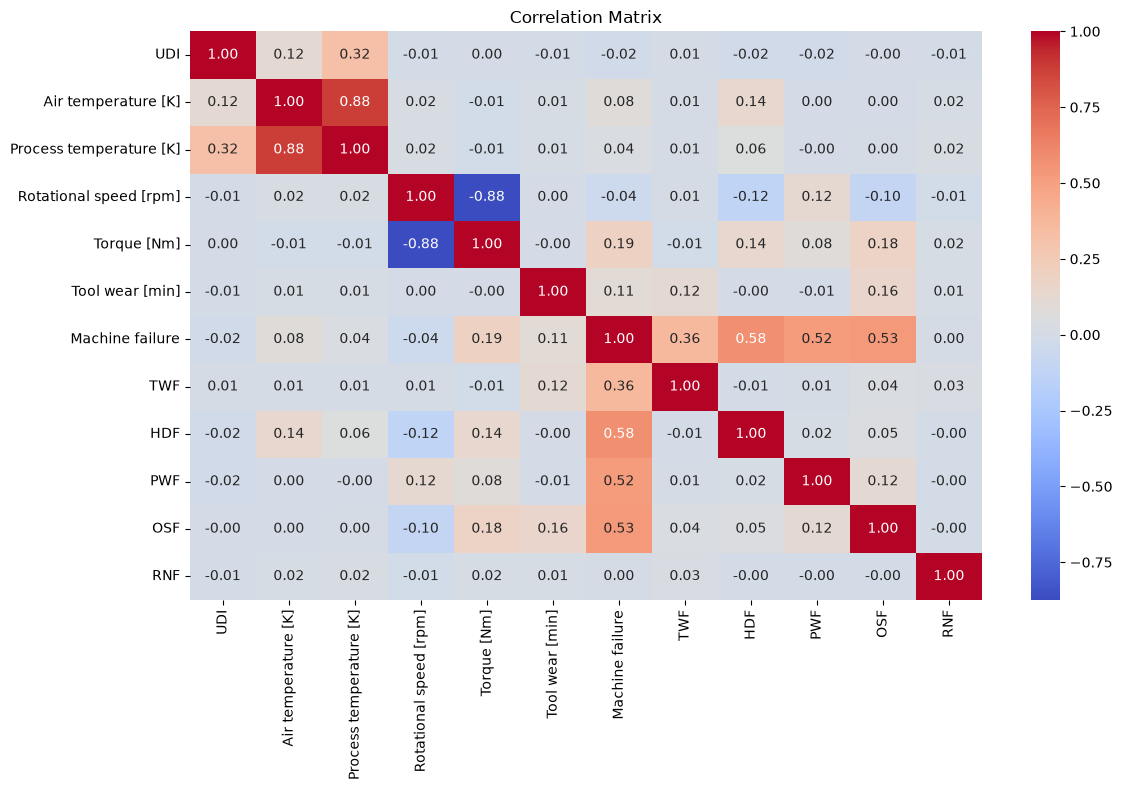

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [42]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

X = df[features]
y = df["Machine failure"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)

Features:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Target:
Machine failure

X Shape: (10000, 5)
y Shape: (10000,)


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (8000, 5)
y_train: (8000,)

Testing data:
X_test: (2000, 5)
y_test: (2000,)


In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Baseline model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9815
Precision: 0.7313432835820896
Recall   : 0.7205882352941176
F1 Score : 0.725925925925926

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.73      0.72      0.73        68

    accuracy                           0.98      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.98      0.98      0.98      2000


Confusion Matrix:
[[1914   18]
 [  19   49]]


In [45]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Train Logistic Regression
logistic_model.fit(X_train, y_train)

# Predict
y_pred_lr = logistic_model.predict(X_test)

# Evaluation
print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression
Accuracy : 0.821
Precision: 0.13930348258706468
Recall   : 0.8235294117647058
F1 Score : 0.23829787234042554

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000


Confusion Matrix:
[[1586  346]
 [  12   56]]


In [46]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

# Evaluation
print("Gradient Boosting")
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1 Score :", f1_score(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Gradient Boosting
Accuracy : 0.9845
Precision: 0.8627450980392157
Recall   : 0.6470588235294118
F1 Score : 0.7394957983193278

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.86      0.65      0.74        68

    accuracy                           0.98      2000
   macro avg       0.93      0.82      0.87      2000
weighted avg       0.98      0.98      0.98      2000


Confusion Matrix:
[[1925    7]
 [  24   44]]


Torque [Nm]                0.328165
Rotational speed [rpm]     0.306219
Tool wear [min]            0.224945
Air temperature [K]        0.083586
Process temperature [K]    0.057085
dtype: float64


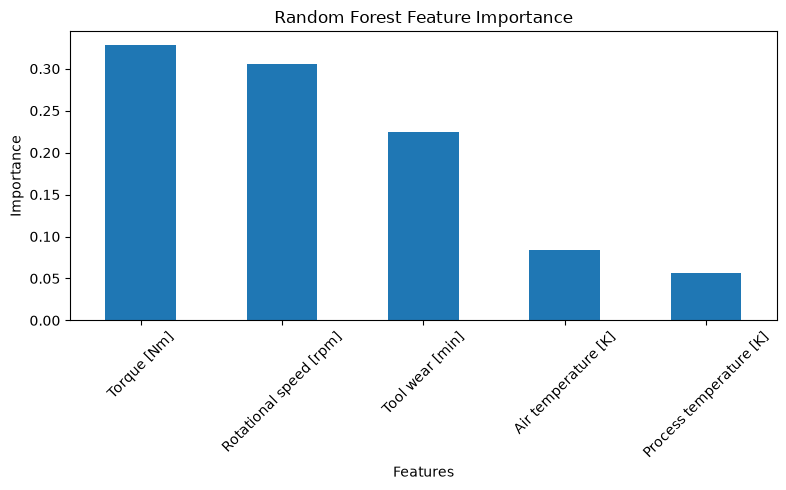

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

plt.figure(figsize=(8, 5))
feature_importance.plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Random Forest probabilities
y_prob_rf = model.predict_proba(X_test)[:, 1]

thresholds = [0.5, 0.4, 0.3]

for threshold in thresholds:
    y_pred_threshold = (y_prob_rf >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print("Precision:", precision_score(y_test, y_pred_threshold))
    print("Recall   :", recall_score(y_test, y_pred_threshold))
    print("F1 Score :", f1_score(y_test, y_pred_threshold))


Threshold: 0.5
Precision: 0.7313432835820896
Recall   : 0.7205882352941176
F1 Score : 0.725925925925926

Threshold: 0.4
Precision: 0.6071428571428571
Recall   : 0.75
F1 Score : 0.6710526315789473

Threshold: 0.3
Precision: 0.48717948717948717
Recall   : 0.8382352941176471
F1 Score : 0.6162162162162163


In [49]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Probabilities
y_prob_rf = model.predict_proba(X_test)[:, 1]
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("Random Forest")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC :", average_precision_score(y_test, y_prob_rf))

print("\nGradient Boosting")
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))
print("PR-AUC :", average_precision_score(y_test, y_prob_gb))

Random Forest
ROC-AUC: 0.9677833089757643
PR-AUC : 0.7717671205916082

Gradient Boosting
ROC-AUC: 0.9656139629764949
PR-AUC : 0.7757147158774254


In [50]:
import joblib
import os

os.makedirs("../ml_model", exist_ok=True)

model_path = "../ml_model/predictive_maintenance_model.pkl"

joblib.dump(model, model_path)

print("Model saved successfully!")
print("Path:", model_path)

Model saved successfully!
Path: ../ml_model/predictive_maintenance_model.pkl


In [51]:
import numpy as np

# Failure probabilities for the complete test set
test_probabilities = model.predict_proba(X_test)[:, 1]

print("Minimum probability:", test_probabilities.min())
print("Maximum probability:", test_probabilities.max())
print("Mean probability:", test_probabilities.mean())

print("\nPercentiles:")
print("25th:", np.percentile(test_probabilities, 25))
print("50th:", np.percentile(test_probabilities, 50))
print("75th:", np.percentile(test_probabilities, 75))
print("90th:", np.percentile(test_probabilities, 90))

Minimum probability: 0.0
Maximum probability: 0.995
Mean probability: 0.0457375

Percentiles:
25th: 0.0
50th: 0.0
75th: 0.005
90th: 0.09050000000000068


In [52]:
threshold_results = []

for threshold in np.arange(0.1, 1.0, 0.1):
    y_pred_threshold = (y_prob_rf >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": round(threshold, 1),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4)
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df)

   Threshold  Precision  Recall      F1
0        0.1     0.3198  0.9265  0.4755
1        0.2     0.4296  0.8971  0.5810
2        0.3     0.5044  0.8382  0.6298
3        0.4     0.6071  0.7500  0.6711
4        0.5     0.7313  0.7206  0.7259
5        0.6     0.8491  0.6618  0.7438
6        0.7     0.8182  0.5294  0.6429
7        0.8     0.9333  0.4118  0.5714
8        0.9     1.0000  0.1176  0.2105


In [55]:
# Failure probability
probability = model.predict_proba(input_data)[0][1]

# Failure prediction threshold
FAILURE_THRESHOLD = 0.60
prediction = int(probability >= FAILURE_THRESHOLD)

# Risk level
if probability >= 0.70:
    risk = "HIGH"
elif probability >= 0.40:
    risk = "MEDIUM"
else:
    risk = "LOW"

NameError: name 'input_data' is not defined